## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

!pip install lightgbm wandb -q
import lightgbm as lgb
import wandb

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
%matplotlib inline

# set a constant seed
SEED = 42
np.random.seed(SEED)


### WanDB Setup

Run this once per session. Get a free API key from [wandb.ai/authorize](https://wandb.ai/authorize).

In [ ]:
wandb.login()  # paste your API key when prompted

WANDB_PROJECT = "ieee-fraud-detection"


/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 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


wandb: WARNING Invalid choice


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kov-koalla (kov-koalla-kyiv-school-of-economics) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


*Note: WanDB setup was made with a help from Gemini to correctly connect to it*

## Load data

In [ ]:
from google.colab import files
files.upload()  # select kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c ieee-fraud-detection
!unzip -q ieee-fraud-detection.zip -d data/


Saving kaggle.json to kaggle.json
100% 118M/118M [00:00<00:00, 144MB/s]



In [ ]:
def reduce_mem_usage(df, verbose=True):
    # Safely downcasts numeric columns without overflow/precision loss
    start_mem = df.memory_usage().sum() / 1024**2
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        for col in df.columns:
            col_type = df[col].dtype
            if col_type != object and col_type.name != 'category' and not pd.api.types.is_datetime64_any_dtype(df[col]):
                c_min, c_max = df[col].min(), df[col].max()
                if np.isinf(c_min) or np.isinf(c_max):
                    continue
                if str(col_type)[:3] == 'int':
                    if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)
                else:
                    if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Memory usage decreased to {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df


print("Loading Train...")
train_tx = pd.read_csv('data/train_transaction.csv')
train_id = pd.read_csv('data/train_identity.csv')
train = train_tx.merge(train_id, on='TransactionID', how='left')
del train_tx, train_id; gc.collect()
train = reduce_mem_usage(train)

print("\nLoading Test...")
test_tx = pd.read_csv('data/test_transaction.csv')
test_id = pd.read_csv('data/test_identity.csv')
test = test_tx.merge(test_id, on='TransactionID', how='left')
del test_tx, test_id; gc.collect()
test = reduce_mem_usage(test)

# standardize column names (id-01 -> id_01)
train.columns = [c.replace('-', '_') for c in train.columns]
test.columns = [c.replace('-', '_') for c in test.columns]

print(f"\nFinal Train shape: {train.shape}")
print(f"Final Test shape: {test.shape}")


Loading Train...
Memory usage decreased to 1044.70 MB (46.6% reduction)

Loading Test...
Memory usage decreased to 895.89 MB (46.5% reduction)

Final Train shape: (590540, 434)
Final Test shape: (506691, 433)


## Baseline Model Choice

**LightGBM** (Light Gradient Boosting Machine) is a fast, distributed, high-performance gradient boosting framework based on decision tree algorithms used for ranking, classification, and regression.

### Key Features
- **Leaf-wise Tree Growth**: Unlike traditional methods that grow trees level-wise (horizontally), LightGBM grows trees leaf-wise (vertically) by picking the leaf with the maximum delta loss, reducing loss faster. Can produce overfitting, but that's not our case.
- **Histogram-based Algorithm**: Buckets continuous feature values into discrete bins to speed up training and lower memory usage. This approach significantly reduces computational complexity and memory usage, especially for datasets with a large number of unique feature values.
- **Gradient-based One-Side Sampling (GOSS)**: Keeps data instances with large gradients and randomly samples instances with small gradients to focus learning on harder data.
- **Exclusive Feature Bundling (EFB)**: Bundles mutually exclusive sparse features together to reduce effective feature dimensionality.
- **Parallel and GPU Training**: LightGBM provides native support for parallel and GPU training, allowing it to leverage multicore processors and GPUs for faster model training.

### Available Boosting Techniques
- Gradient Boosting Decision Tree (**GBDT**) - Dropouts meet Multiple Additive Regression Trees (**DART**)

*Reference: https://medium.com/@soyoungluna/simple-explanation-of-lightgbm-without-complicated-mathematics-973998ec848f$0*

## Feature engineering

1. **Time features** — hour of day / day of week from `TransactionDT` (fraud showed clear time-of-day patterns in EDA).
2. **`TransactionAmt` transforms** — `log1p` (heavy right skew) and the cents/decimal part (often informative for fraud).
3. **`D`-column detrending** — subtract elapsed dataset time from the non-stationary `D` columns, as found during EDA, so trees don't split on values that never occur this early in time again.
4. **Frequency encoding** — for high-cardinality categoricals (`card1`, `addr1`, `P_emaildomain`, `DeviceInfo`), replacing raw IDs with how often they occur.
5. **Label encoding** — for the remaining categorical columns, so LightGBM can consume them natively as `category` dtype.
6. **Drift-prone columns dropped** — `C12, C10, C4, C7` were flagged by adversarial validation in `validation.ipynb` as the strongest train/test drift drivers; we drop them for the baseline to avoid overfitting to a shift that won't hold at test time.


In [ ]:
def engineer_features(train, test):
    train = train.copy()
    test = test.copy()

    # time features
    for df in (train, test):
        df['DT_day'] = df['TransactionDT'] // (3600 * 24)
        df['DT_hour'] = (df['TransactionDT'] // 3600) % 24
        df['DT_dow'] = df['DT_day'] % 7

    # TransactionAmt transforms
    for df in (train, test):
        df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
        df['TransactionAmt_decimal'] = ((df['TransactionAmt'] - df['TransactionAmt'].astype(int)) * 1000).astype(int)

    # detrend non-stationary D-columns (finding from eda.ipynb)
    for col in ['D11', 'D1', 'D15', 'D4', 'D10', 'D2']:
        if col in train.columns:
            train[f'{col}_detrended'] = train[col] - train['TransactionDT'] / 86400
            test[f'{col}_detrended'] = test[col] - test['TransactionDT'] / 86400

    # frequency encoding for high-cardinality categoricals
    freq_cols = ['card1', 'addr1', 'P_emaildomain', 'DeviceInfo']
    for col in freq_cols:
        if col in train.columns:
            freq_map = train[col].value_counts(dropna=False)
            train[f'{col}_freq'] = train[col].map(freq_map)
            test[f'{col}_freq'] = test[col].map(freq_map).fillna(0)

    # label encode remaining categoricals
    cat_cols = train.select_dtypes(include=['object']).columns.tolist()
    for col in cat_cols:
        le = LabelEncoder()
        combined = pd.concat([train[col], test[col]], axis=0).astype(str).fillna('missing')
        le.fit(combined)
        train[col] = le.transform(train[col].astype(str).fillna('missing'))
        test[col] = le.transform(test[col].astype(str).fillna('missing'))
        train[col] = train[col].astype('category')
        test[col] = test[col].astype('category')

    # drop drift-prone columns identified by adversarial validation
    drift_cols = ['C12', 'C10', 'C4', 'C7']
    train = train.drop(columns=[c for c in drift_cols if c in train.columns])
    test = test.drop(columns=[c for c in drift_cols if c in test.columns])

    return train, test


train, test = engineer_features(train, test)
gc.collect()
print("Feature engineering completed")
print(f"Train shape: {train.shape} | Test shape: {test.shape}")


Feature engineering completed
Train shape: (590540, 445) | Test shape: (506691, 444)


## Time-based validation split

Validation strategy: **days 1–122 train, 30-day purge gap (123–152), days 153–182 validation**, so local scores are comparable to what we'll see on the leaderboard


In [ ]:
TRAIN_END_DAY = 122
GAP_END_DAY = 152

train_mask = train['DT_day'] <= TRAIN_END_DAY
val_mask = train['DT_day'] > GAP_END_DAY

drop_cols = ['isFraud', 'TransactionID', 'TransactionDT', 'DT_day']
feature_cols = [c for c in train.columns if c not in drop_cols]

X_train, y_train = train.loc[train_mask, feature_cols], train.loc[train_mask, 'isFraud']
X_val, y_val = train.loc[val_mask, feature_cols], train.loc[val_mask, 'isFraud']

print(f"Train fold: {X_train.shape} | Fraud rate: {y_train.mean():.4%}")
print(f"Val fold:   {X_val.shape} | Fraud rate: {y_val.mean():.4%}")

cat_features = [c for c in feature_cols if str(X_train[c].dtype) == 'category']
print(f"\nCategorical features passed to LightGBM: {len(cat_features)}")


Train fold: (420066, 441) | Fraud rate: 3.5197%
Val fold:   (85430, 441) | Fraud rate: 3.5046%

Categorical features passed to LightGBM: 31


##  Baseline model + W&B logging



In [ ]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'max_depth': -1,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'n_estimators': 2000,
    'random_state': SEED,
    'n_jobs': -1,
}

run = wandb.init(project=WANDB_PROJECT, name="lgbm-baseline", config=params, reinit=True)

model = lgb.LGBMClassifier(**params)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['train', 'val'],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100),
        wandb.lightgbm.wandb_callback(),
    ],
)
wandb.lightgbm.log_summary(model.booster_, save_model_checkpoint=False)


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 14785, number of negative: 405281
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.480284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 35984
[LightGBM] [Info] Number of data points in the train set: 420066, number of used features: 439
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035197 -> initscore=-3.310968
[LightGBM] [Info] Start training from score -3.310968
Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.955658	val's auc: 0.903666
[200]	train's auc: 0.974715	val's auc: 0.910584
[300]	train's auc: 0.983325	val's auc: 0.910441
[

**Early stopping, briefly.** During training with `eval_set`, LightGBM checks the validation metric (`val` AUC) after every boosting round and stops once it hasn't improved for `stopping_rounds` consecutive rounds. `best_iteration_` records the round where validation performance actually peaked —
this avoids both underfitting (too few trees) and overfitting (too many), without us having to guess `n_estimators` by hand.

In [ ]:
# eval on the held-out val fold
val_pred = model.predict_proba(X_val, num_iteration=model.best_iteration_)[:, 1]

val_auc = roc_auc_score(y_val, val_pred)
val_pr_auc = average_precision_score(y_val, val_pred)
val_f1 = f1_score(y_val, (val_pred > 0.5).astype(int))

print(f"Validation ROC-AUC:  {val_auc:.4f}")
print(f"Validation PR-AUC:   {val_pr_auc:.4f}")
print(f"Validation F1 (@0.5): {val_f1:.4f}")

wandb.log({
    'final/val_roc_auc': val_auc,
    'final/val_pr_auc': val_pr_auc,
    'final/val_f1': val_f1,
    'final/best_iteration': model.best_iteration_,
})


Validation ROC-AUC:  0.9118
Validation PR-AUC:   0.5634
Validation F1 (@0.5): 0.5022


## Feature importance

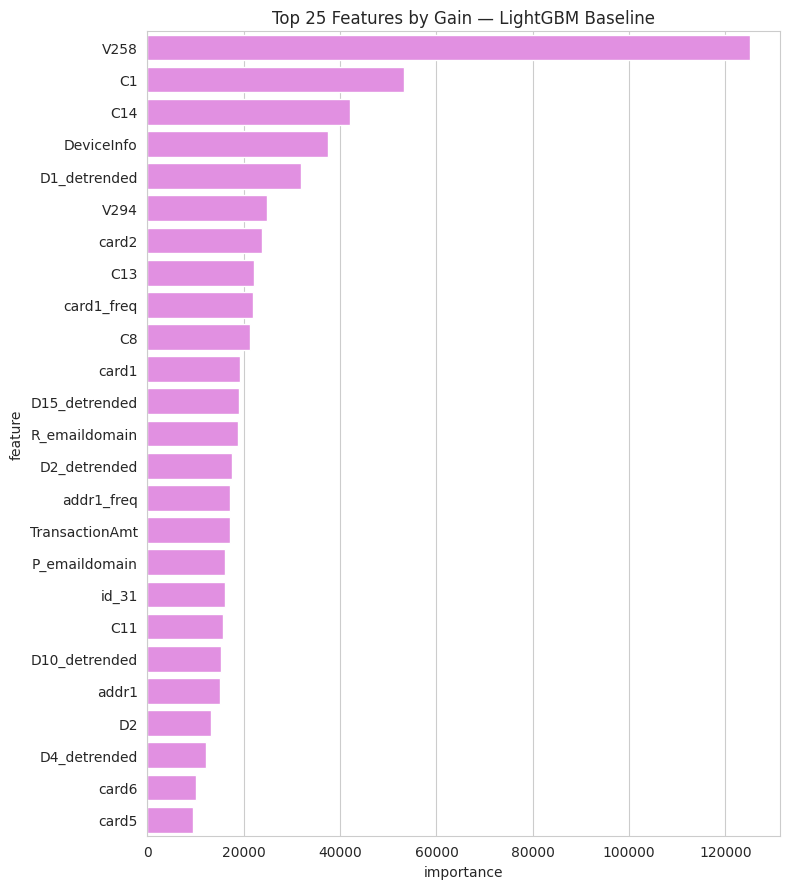

final/best_iteration,▁
final/val_f1,▁
final/val_pr_auc,▁
final/val_roc_auc,▁
iteration,▁▁▁▁▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇████
train_auc,▁▂▂▃▃▃▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█████████████
val_auc,▁▃▄▆▆▆▇▇▇▇██████████████████████████████
best_iteration,476
final/best_iteration,476
final/val_f1,0.50219
final/val_pr_auc,0.5634


In [ ]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.booster_.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False)

top_n = 25
fig, ax = plt.subplots(figsize=(8, 9))
sns.barplot(data=importance.head(top_n), x='importance', y='feature', ax=ax, color='violet')
ax.set_title(f'Top {top_n} Features by Gain — LightGBM Baseline')
plt.tight_layout()
plt.show()

wandb.log({
    'feature_importance_plot': wandb.Image(fig),
    'feature_importance_table': wandb.Table(dataframe=importance.head(50)),
})
run.finish()


## Parameters tuning log

A small manual grid over the parameters that matter most for gradient boosting on this dataset
(`num_leaves`, `learning_rate`, `min_child_samples`). Each configuration is logged as its **own W&B run**.


In [ ]:
param_grid = [
    {'num_leaves': 31,  'learning_rate': 0.1,  'min_child_samples': 20},
    {'num_leaves': 64,  'learning_rate': 0.05, 'min_child_samples': 50},
    {'num_leaves': 128, 'learning_rate': 0.05, 'min_child_samples': 100},
    {'num_leaves': 64,  'learning_rate': 0.02, 'min_child_samples': 50},
]

tuning_results = []

for i, grid_params in enumerate(param_grid):
    run_params = {**params, **grid_params, 'n_estimators': 1000}

    run = wandb.init(project=WANDB_PROJECT, name=f"lgbm-tune-{i}", config=run_params, reinit=True)

    m = lgb.LGBMClassifier(**run_params)
    m.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )
    pred = m.predict_proba(X_val, num_iteration=m.best_iteration_)[:, 1]
    auc = roc_auc_score(y_val, pred)

    wandb.log({'final/val_roc_auc': auc, 'final/best_iteration': m.best_iteration_})
    run.finish()

    tuning_results.append({**grid_params, 'val_auc': auc, 'best_iteration': m.best_iteration_})
    print(f"Run {i}: {grid_params} -> AUC={auc:.4f}")

tuning_df = pd.DataFrame(tuning_results).sort_values('val_auc', ascending=False)
tuning_df


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 14785, number of negative: 405281
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 4.413300 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35984
[LightGBM] [Info] Number of data points in the train set: 420066, number of used features: 439
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035197 -> initscore=-3.310968
[LightGBM] [Info] Start training from score -3.310968


final/best_iteration,▁
final/val_roc_auc,▁
final/best_iteration,292
final/val_roc_auc,0.90861


Run 0: {'num_leaves': 31, 'learning_rate': 0.1, 'min_child_samples': 20} -> AUC=0.9086


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 14785, number of negative: 405281
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.561214 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 35984
[LightGBM] [Info] Number of data points in the train set: 420066, number of used features: 439
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035197 -> initscore=-3.310968
[LightGBM] [Info] Start training from score -3.310968


final/best_iteration,▁
final/val_roc_auc,▁
final/best_iteration,204
final/val_roc_auc,0.91068


...

Run 2: {'num_leaves': 128, 'learning_rate': 0.05, 'min_child_samples': 100} -> AUC=0.9137


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 14785, number of negative: 405281
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 3.778551 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35984
[LightGBM] [Info] Number of data points in the train set: 420066, number of used features: 439
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035197 -> initscore=-3.310968
[LightGBM] [Info] Start training from score -3.310968


final/best_iteration,▁
final/val_roc_auc,▁
final/best_iteration,497
final/val_roc_auc,0.91304


Run 3: {'num_leaves': 64, 'learning_rate': 0.02, 'min_child_samples': 50} -> AUC=0.9130


,num_leaves,learning_rate,min_child_samples,val_auc,best_iteration
2,128,0.05,100,0.913690,160
3,64,0.02,50,0.913042,497
1,64,0.05,50,0.910676,204
0,31,0.10,20,0.908606,292


### Why we scale `best_iteration_` by 1.1x for the final refit

**Why we can't reuse `best_iteration_` we found earlier directly for the final model.** The final refit trains on `X_full = train + val` combined, with no held-out `eval_set` — there's nothing left to monitor, early stopping can't run on this fit at all. We're forced to pick a fixed `n_estimators` up front.

The `best_iteration_` we have (160) was the optimal stopping point on the smaller `X_train`-only fold (~420k rows). `X_full` has ~20% more rows (~505k). More training data generally supports a few more useful trees before overfitting becomes a problem, since each split is estimated with more examples and there's more signal to fit. So reusing only 160 unchanged would likely limit our abilities in training.

**The 1.1x factor** (160 → 176 trees) is a common heuristic fudge factor to compensate for this - *was brainstormed and suggested by Claude.*

We pick the best parameters and train the model once more on them for the best result

## Predictions for the leaderboard


In [13]:
best_params = {
    **params,
    **tuning_df.iloc[0][['num_leaves', 'learning_rate', 'min_child_samples']].to_dict()
}

best_params['num_leaves'] = int(best_params['num_leaves'])
best_params['min_child_samples'] = int(best_params['min_child_samples'])

# scale n_estimators by 10% to account for retraining on a larger dataset
best_params['n_estimators'] = int(model.best_iteration_ * 1.1)

# remove early stopping argument if present in base params so fit() doesn't throw a warning
best_params.pop('early_stopping_rounds', None)

X_full = pd.concat([X_train, X_val], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X_full, y_full)

X_test = test[feature_cols]
test_pred = final_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'TransactionID': test['TransactionID'],
    'isFraud': test_pred,
})

submission.to_csv('submission_baseline.csv', index=False)
submission.head()

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 17779, number of negative: 487717
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 6.396912 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40670
[LightGBM] [Info] Number of data points in the train set: 505496, number of used features: 439
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035171 -> initscore=-3.311717
[LightGBM] [Info] Start training from score -3.311717


,TransactionID,isFraud
0,3663549,0.000638
1,3663550,0.000755
2,3663551,0.001872
3,3663552,0.000960
4,3663553,0.001282


In [14]:
# submission to Kaggle
!kaggle competitions submit -c ieee-fraud-detection -f submission_baseline.csv -m "LightGBM baseline"


100% 14.2M/14.2M [00:00<00:00, 43.4MB/s]
Successfully submitted to IEEE-CIS Fraud Detection

### Local validation vs. leaderboard

| Split                | ROC-AUC  |
|-----------------------|----------|
| Local validation (baseline params, cell 14) | 0.9118 |
| Local validation (tuned params, used for final submission) | 0.9137 |
| Public leaderboard     | 0.935025 |
| Private leaderboard    | 0.898868 |

**Public Leaderboard Score is ~0.021–0.023 *higher* than local validation; Private Leaderboard Score is ~0.013–0.015 *lower*.**
This is not a simple "overfit to validation" pattern — if that were happening, both public and private would sit below local validation. Instead we see a pretty big gap *between* public and private (0.036), which points to distribution drift between the two portions of the actual test set
rather than a flaw in the holdout itself.

This is consistent with the caveat carried over from `validation.ipynb`: adversarial validation flagged the `C`-columns (`C12, C10, C4, C7`, already dropped) and several time-correlated features as
the strongest train/test drift drivers. Since Kaggle's public/private split for this competition is itself time-based, it's plausible the private portion is more temporally distant from train than the public portion is — meaning our 30-day-gap local split may still underestimate drift relative to the
private set specifically, even though it filters out the "easy" case of test-adjacent leakage. In short: the holdout is directionally trustworthy but not tight enough to fully explain the public/private divergence — that gap is a property of the competition's time split and we cannot fully omit it.

## Conclusions

- **Model**: LightGBM (GBDT) on ~440-feature tabular data (after frequency/label encoding and drift-column removal), trained with a time-based holdout (train ≤ day 122, 30-day purge gap, validate on days 153–182) that mirrors the real train→test time gap in the competition.
- **Tuning**: a 4-point manual grid over `num_leaves`, `learning_rate` `min_child_samples` improved local validation AUC from 0.9118 → 0.9137 (`num_leaves=128, lr=0.05, min_child_samples=100`, best_iteration=160). The final submission model was refit on train+validation combined with this config and `n_estimators` scaled by 1.1x over the early-stopped round count.
- **Result**: local validation ROC-AUC 0.9137 → Public LB 0.935025, Private LB 0.898868.
- **Is the baseline adequate?** Yes, as a reference point — an ROC-AUC around 0.90–0.91 is a reasonable, leakage-checked LightGBM result for this task. It may not be the final model, but it gives a solid ground to look at.
- **Main caveat**: the 0.036 gap between public and private leaderboard scores is larger than the local train/val gap would suggest, and is most likely driven by time-based drift in the test set that our holdout — despite the purge gap — doesn't fully capture. This is worth flagging explicitly when comparing the upcoming deep learning model's public vs. private scores too, so a private-score
regression isn't misread as a modeling failure when it may partly be this same drift effect.

*Notes: conclusion text was polished with the help of Claude.*


AI Notice: Some parts of the code was generated/corrected with Gemini/Claude. I used it when I wasn't sure in syntax/had some bugs while running code. All prompts looked like *"code cell + error. Please help me find our what is wrong and how to fix it"* or *"show me example of simple implementation of LigthGBM"*.